In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
df = pd.read_csv("assets/datasets/breast-cancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [25]:
print("=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===")
vazios_por_coluna = df.isnull().sum()
print(vazios_por_coluna[vazios_por_coluna > 0])

if vazios_por_coluna.sum() == 0:
    print("Excelente! Nenhuma coluna possui dados em branco.")
else:
    print(f"\nTotal de células em branco no dataset: {vazios_por_coluna.sum()}")

print("\n" + "="*50 + "\n")

=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===
Series([], dtype: int64)
Excelente! Nenhuma coluna possui dados em branco.




In [26]:
parametros = {'n_neighbors': list(range(1, 22, 2))}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    parametros,
    cv=cv_folds,
    scoring='accuracy'
)

grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
melhor_knn = grid_search.best_estimator_

print(f"-> O melhor valor de K encontrado foi: {best_k}\n")

-> O melhor valor de K encontrado foi: 3



KNN model

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

parametros = {'n_neighbors': list(range(1, 22, 2))}
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(KNeighborsClassifier(), parametros, cv=cv_folds, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"-> O melhor valor de K encontrado foi: {best_k}\n")

-> O melhor valor de K encontrado foi: 3



Naive-Baynes

In [28]:
naive_bayes = GaussianNB()

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

naive_bayes.fit(X_train_scaled, y_train)

print("Modelo Naive Bayes treinado com sucesso!")

Modelo Naive Bayes treinado com sucesso!


Tree Decision

In [29]:
parametros_arvore = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4, 5, 10]
}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_arvore = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parametros_arvore,
    cv=cv_folds,
    scoring='accuracy'
)

grid_arvore.fit(X_train, y_train)

melhor_arvore = grid_arvore.best_estimator_

print(f"-> Melhores parâmetros encontrados: {grid_arvore.best_params_}\n")

-> Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1}



Random Florest

In [30]:
parametros_floresta = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_floresta = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    parametros_floresta,
    cv=cv_folds,
    scoring='accuracy'
)

grid_floresta.fit(X_train, y_train)

melhor_floresta = grid_floresta.best_estimator_

print(f"-> Melhores parâmetros encontrados: {grid_floresta.best_params_}\n")

-> Melhores parâmetros encontrados: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 200}



Neural Network

In [31]:
parametros_mlp = {
    'hidden_layer_sizes': [(50,), (30, 15), (50, 25)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'max_iter': [500]
}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_mlp = GridSearchCV(
    MLPClassifier(random_state=42, early_stopping=True),
    parametros_mlp,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1
)
grid_mlp.fit(X_train_scaled, y_train)

melhor_mlp = grid_mlp.best_estimator_

print(f"-> Melhores parâmetros da Rede Neural: {grid_mlp.best_params_}\n")

-> Melhores parâmetros da Rede Neural: {'activation': 'tanh', 'hidden_layer_sizes': (50, 25), 'max_iter': 500, 'solver': 'adam'}



SVM

In [32]:

parametros_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    parametros_svm,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1
)

print("Iniciando o Grid Search para o SVM (isso pode levar de 1 a 2 minutos)...")
grid_svm.fit(X_train_scaled, y_train)

melhor_svm = grid_svm.best_estimator_

print(f"\n-> Melhores parâmetros do SVM encontrados: {grid_svm.best_params_}\n")

Iniciando o Grid Search para o SVM (isso pode levar de 1 a 2 minutos)...

-> Melhores parâmetros do SVM encontrados: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}



Comite

=== MATRIZ DE CONFUSÃO - SUPER COMITÊ DE 6 MODELOS ===
[[71  1]
 [ 3 39]]


=== RELATÓRIO DE CLASSIFICAÇÃO - SUPER COMITÊ ===
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        72
 Maligno (M)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



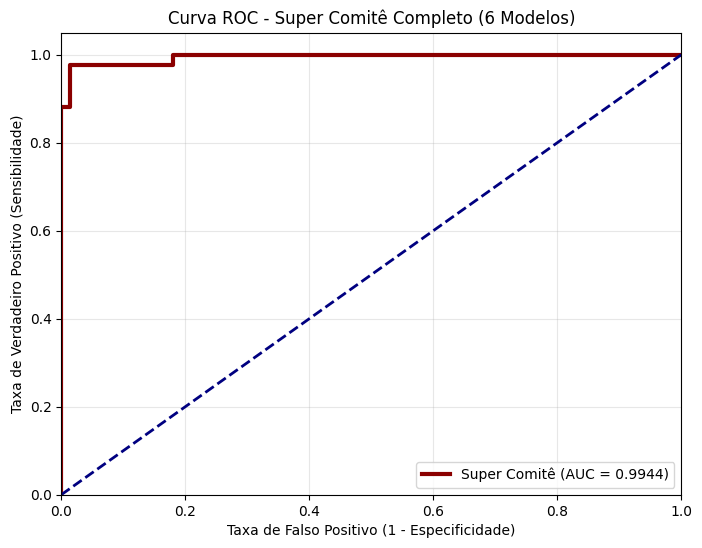

In [33]:
super_comite = VotingClassifier(
    estimators=[
        ('svm', melhor_svm),
        ('rf', melhor_floresta),
        ('mlp', melhor_mlp),
        ('knn', melhor_knn),
        ('dt', melhor_arvore),
        ('nb', naive_bayes)
    ],
    voting='soft'
)

super_comite.fit(X_train_scaled, y_train)

y_probs_comite = super_comite.predict_proba(X_test_scaled)[:, 1]

threshold = 0.40

y_pred_comite = (y_probs_comite >= threshold).astype(int)

y_probs_comite = super_comite.predict_proba(X_test_scaled)[:, 1]

print("=== MATRIZ DE CONFUSÃO - SUPER COMITÊ DE 6 MODELOS ===")
print(confusion_matrix(y_test, y_pred_comite))

print("\n" + "="*40)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO - SUPER COMITÊ ===")
print(classification_report(y_test, y_pred_comite, target_names=['Benigno (B)', 'Maligno (M)']))

fpr_c, tpr_c, _ = roc_curve(y_test, y_probs_comite)
roc_auc_c = auc(fpr_c, tpr_c)

plt.figure(figsize=(8, 6))
plt.plot(fpr_c, tpr_c, color='darkred', lw=3, label=f'Super Comitê (AUC = {roc_auc_c:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Curva ROC - Super Comitê Completo (6 Modelos)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [34]:
from sklearn.metrics import accuracy_score

acc_comite = accuracy_score(y_test, y_pred_comite)

print(f"\nComitê: {acc_comite:.4f}")


Comitê: 0.9649


In [35]:
tabela_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()) + ['Comitê'],
    'Accuracy': list(resultados.values()) + [acc_comite]
})

tabela_resultados = tabela_resultados.sort_values(
    by='Accuracy',
    ascending=False
)

print(tabela_resultados)

          Modelo  Accuracy
5            SVM  0.982456
3  Random Forest  0.973684
4            MLP  0.964912
6         Comitê  0.964912
0            KNN  0.938596
2         Árvore  0.929825
1    Naive Bayes  0.921053


In [36]:
cm = confusion_matrix(y_test, y_pred_comite)

tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

TN: 71
FP: 1
FN: 3
TP: 39


In [37]:
y_pred_svm = melhor_svm.predict(X_test_scaled)

cm_svm = confusion_matrix(y_test, y_pred_svm)

tn, fp, fn, tp = cm_svm.ravel()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

TN: 72
FP: 0
FN: 2
TP: 40


In [38]:
y_probs_svm = melhor_svm.predict_proba(X_test_scaled)[:,1]

for limite in [0.50, 0.45, 0.40, 0.35, 0.30]:
    y_pred = (y_probs_svm >= limite).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(
        f"Threshold={limite:.2f} "
        f"FP={fp} "
        f"FN={fn}"
    )

Threshold=0.50 FP=0 FN=2
Threshold=0.45 FP=0 FN=2
Threshold=0.40 FP=0 FN=2
Threshold=0.35 FP=0 FN=1
Threshold=0.30 FP=1 FN=1
